# Exploratory Data Analysis (EDA) — Student Performance Dataset

**Goal:** explore a dataset to uncover patterns, trends, and the key factors
that influence student exam scores.

**Covers:** statistical summaries, distributions, correlation analysis,
categorical group comparisons, and structured insights.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("../data/student_performance_data.csv")
df.head()

,StudentID,Gender,StudyHoursPerDay,AttendancePercent,SleepHoursPerDay,ParentalEducation,ExtracurricularActivities,InternetAccess,ExamScore
0,STU2000,Female,3.9,87.0,4.2,High School,No,Yes,74.7
1,STU2001,Male,3.8,83.0,7.3,Masters,Yes,Yes,74.8
2,STU2002,Male,6.1,60.6,5.5,High School,Yes,Yes,88.3
3,STU2003,Female,1.5,63.7,5.7,Bachelors,Yes,Yes,59.5
4,STU2004,Male,5.5,76.6,5.7,Bachelors,Yes,No,79.2


## 1. Statistical Summary

In [2]:
print("Shape:", df.shape)
df.info()

Shape: (600, 9)
<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  600 non-null    str    
 1   Gender                     600 non-null    str    
 2   StudyHoursPerDay           600 non-null    float64
 3   AttendancePercent          600 non-null    float64
 4   SleepHoursPerDay           600 non-null    float64
 5   ParentalEducation          600 non-null    str    
 6   ExtracurricularActivities  600 non-null    str    
 7   InternetAccess             600 non-null    str    
 8   ExamScore                  600 non-null    float64
dtypes: float64(4), str(5)
memory usage: 42.3 KB


In [3]:
df.describe()

,StudyHoursPerDay,AttendancePercent,SleepHoursPerDay,ExamScore
count,600.000000,600.00000,600.000000,600.000000
mean,3.985000,77.68100,6.441167,75.866833
std,1.988936,12.28242,1.289532,12.027092
min,0.000000,40.00000,3.000000,42.700000
25%,2.600000,69.60000,5.600000,67.800000
50%,3.900000,78.35000,6.400000,76.050000
75%,5.325000,86.10000,7.300000,83.925000
max,10.200000,100.00000,10.000000,100.000000


In [4]:
print("Missing values:", df.isna().sum().sum())

Missing values: 0


## 2. Distributions (Univariate Analysis)

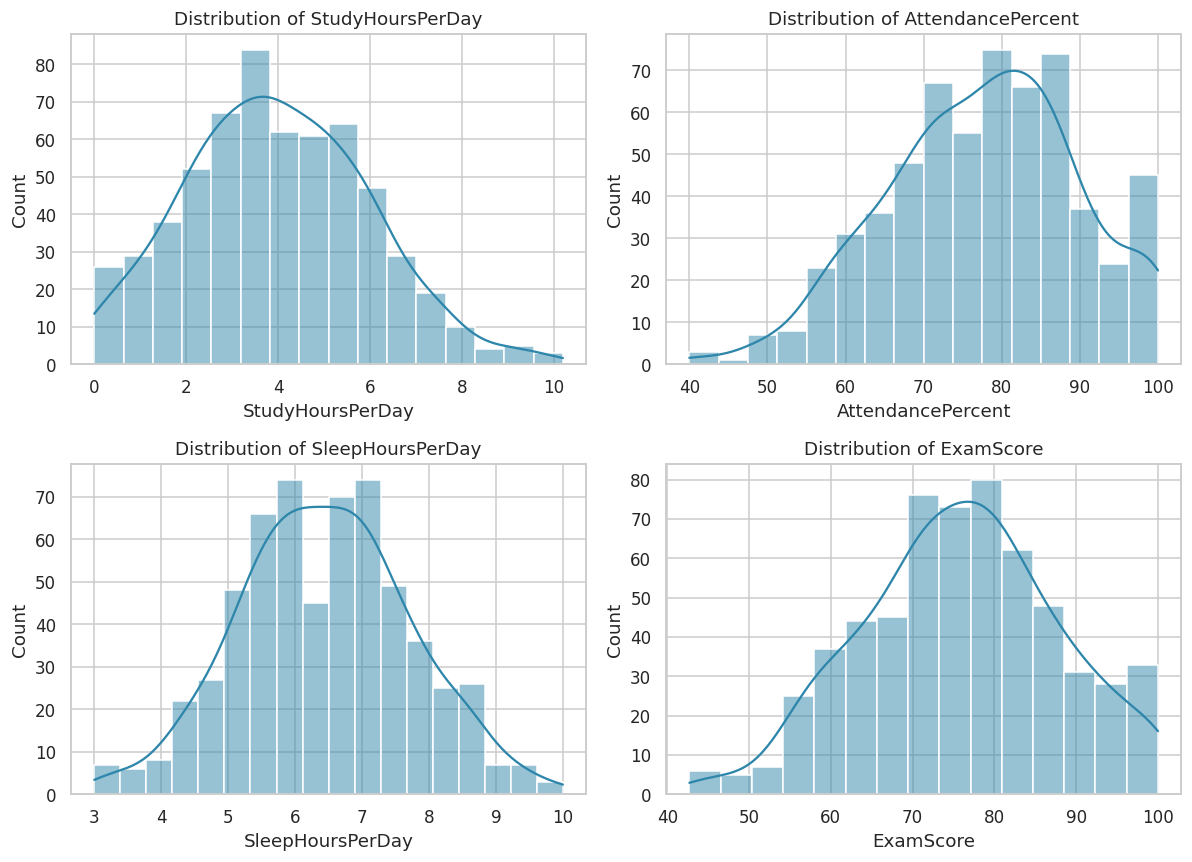

In [5]:
numeric_cols = ["StudyHoursPerDay", "AttendancePercent", "SleepHoursPerDay", "ExamScore"]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#2E86AB")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

## 3. Correlation Analysis

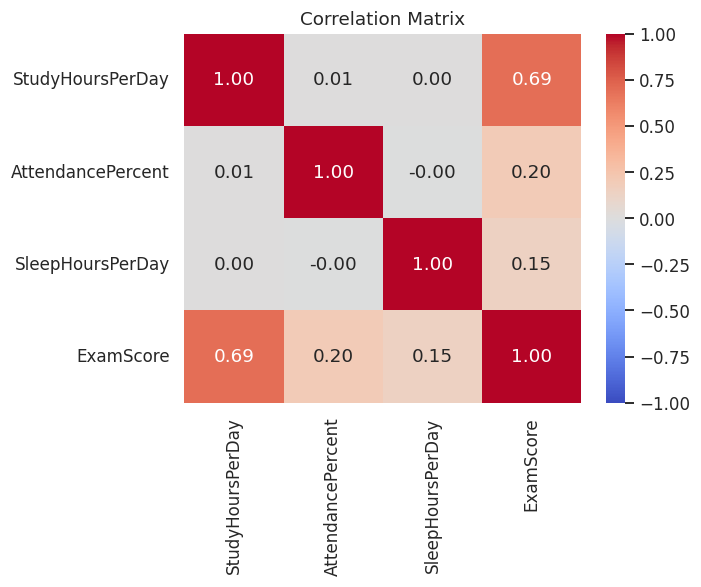

StudyHoursPerDay     0.691827
AttendancePercent    0.198170
SleepHoursPerDay     0.146669
Name: ExamScore, dtype: float64

In [6]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(6.5, 5.5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

corr["ExamScore"].drop("ExamScore").sort_values(ascending=False)

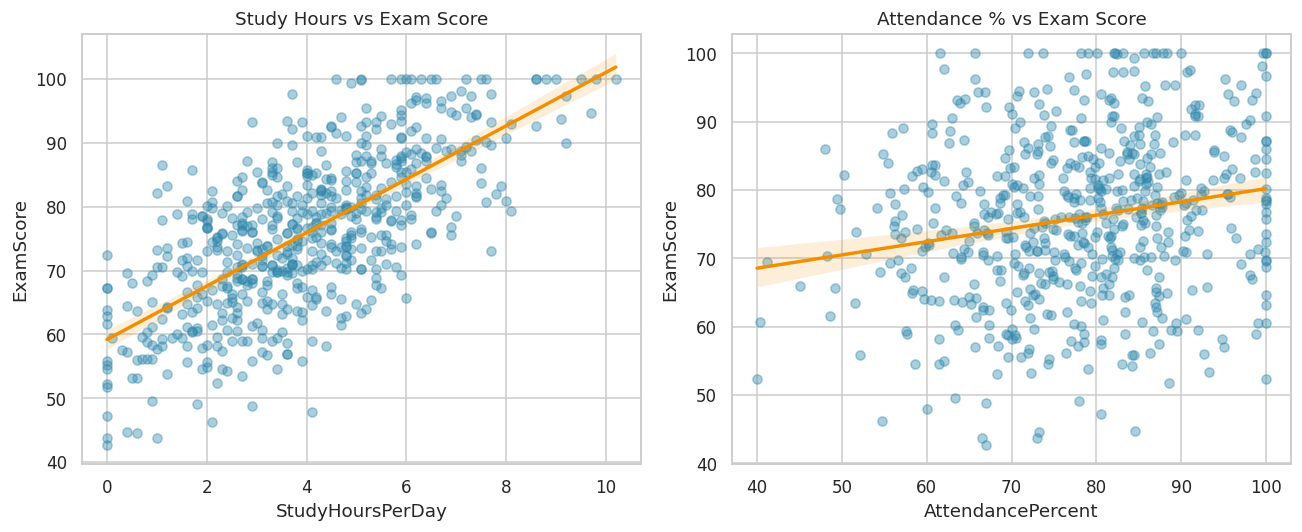

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.regplot(data=df, x="StudyHoursPerDay", y="ExamScore", ax=axes[0],
            scatter_kws={"alpha": 0.4, "color": "#2E86AB"}, line_kws={"color": "#F18F01"})
axes[0].set_title("Study Hours vs Exam Score")
sns.regplot(data=df, x="AttendancePercent", y="ExamScore", ax=axes[1],
            scatter_kws={"alpha": 0.4, "color": "#2E86AB"}, line_kws={"color": "#F18F01"})
axes[1].set_title("Attendance % vs Exam Score")
plt.tight_layout()
plt.show()

## 4. Categorical Factors

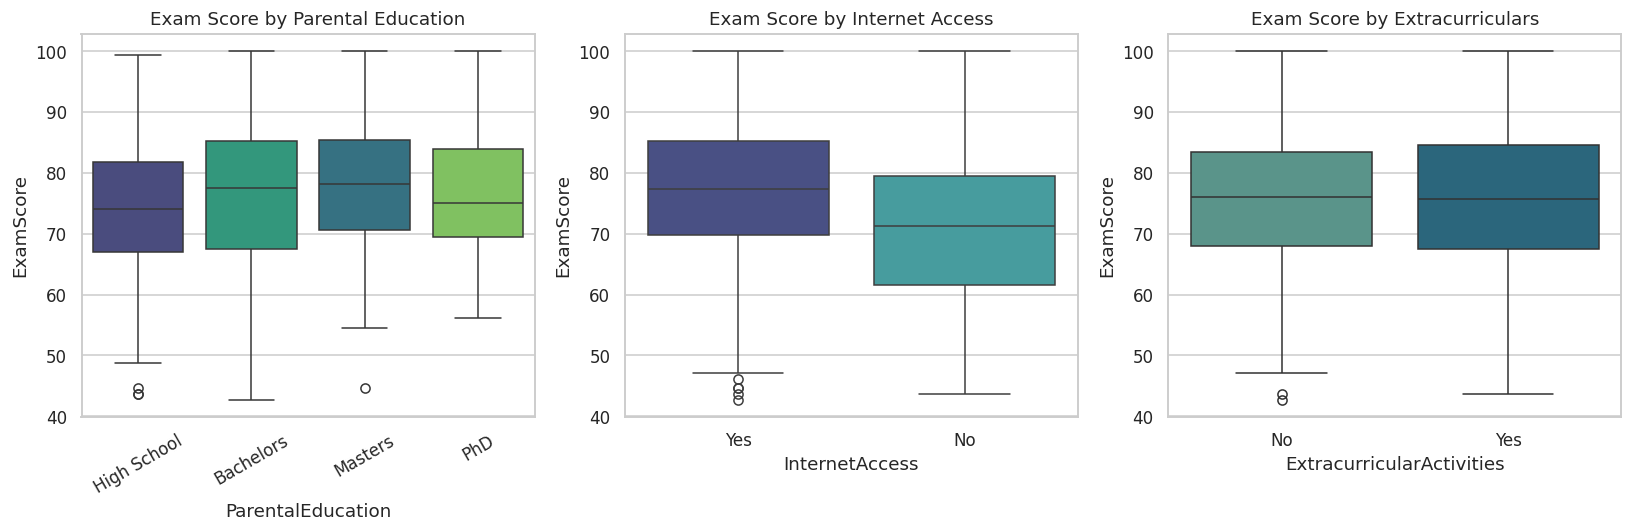

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(data=df, x="ParentalEducation", y="ExamScore", ax=axes[0],
            order=["High School", "Bachelors", "Masters", "PhD"], hue="ParentalEducation",
            palette="viridis", legend=False)
axes[0].set_title("Exam Score by Parental Education")
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df, x="InternetAccess", y="ExamScore", ax=axes[1], hue="InternetAccess",
            palette="mako", legend=False)
axes[1].set_title("Exam Score by Internet Access")

sns.boxplot(data=df, x="ExtracurricularActivities", y="ExamScore", ax=axes[2],
            hue="ExtracurricularActivities", palette="crest", legend=False)
axes[2].set_title("Exam Score by Extracurriculars")
plt.tight_layout()
plt.show()

In [9]:
df.groupby("ParentalEducation")["ExamScore"].mean().reindex(
    ["High School", "Bachelors", "Masters", "PhD"]
).round(1)

ParentalEducation
High School    73.8
Bachelors      76.2
Masters        77.9
PhD            77.4
Name: ExamScore, dtype: float64

## 5. Key Insights

- **Study hours** has the strongest relationship with exam score (correlation ≈ 0.69) —
  by far the biggest lever a student controls directly.
- Students with **internet access** score about 5 points higher on average.
- Higher **parental education** level is associated with progressively higher average scores.
- **Attendance** and **sleep** both show positive but weaker correlations — supportive,
  not decisive, factors.
- Overall: consistent study habits matter more than any single background factor in this data.
